### k means(평균) 알고리즘

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import set_config
set_config(display="text")

from sklearn.cluster import KMeans

import warnings
warnings.filterwarnings('ignore')

### 데이터 만들기
##### - 사람들의 키와 몸무게 데이터를 만들어 보자

In [24]:
df = pd.DataFrame(columns=['height', 'weight'])
df.loc[0] = [185, 60]
df.loc[1] = [180, 60]
df.loc[2] = [185, 70]
df.loc[3] = [165, 63]
df.loc[4] = [155, 68]
df.loc[5] = [170, 75]
df.loc[6] = [175, 80]
print(df)
print(df.values)

   height  weight
0     185      60
1     180      60
2     185      70
3     165      63
4     155      68
5     170      75
6     175      80
[[185  60]
 [180  60]
 [185  70]
 [165  63]
 [155  68]
 [170  75]
 [175  80]]


### 데이터 시각화
##### - 데이터를 차트에 시각화한다.

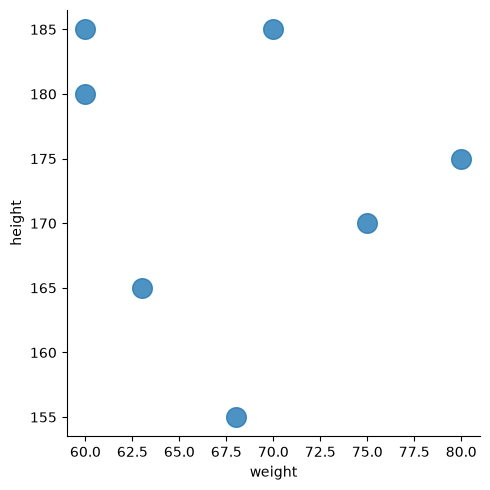

In [25]:
sns.lmplot(data=df, x='weight', y='height', fit_reg=False, scatter_kws={'s':200})
# fit_reg=False 회귀선 없이

###  k 평균 군집화
##### - sklearn의 kmean 라이브러리에 데이터를 활용하여, 데이터를 군집화한다.

In [26]:
data_points = df.values
# 학습
kmeans = KMeans(n_clusters=3).fit(data_points)  # 3개 클러스터

In [27]:
# 아래 명령어로 각 군집의 중심 위치(클러스터)를 확인 할 수 있음.

kmeans.cluster_centers_ # 3개 cluster 정보를 가지고 있는 변수(좌표 값)

array([[183.33333333,  63.33333333],
       [160.        ,  65.5       ],
       [172.5       ,  77.5       ]])

In [29]:
# 데이터가 어느 군집에 소속되어 있는 지 데이터프레임 cluster_id 컬럼에 저장
# kmeans++
df['cluster_id'] = kmeans.labels_
df.head(7)

,height,weight,cluster_id
0,185,60,0
1,180,60,0
2,185,70,0
3,165,63,1
4,155,68,1
5,170,75,2
6,175,80,2


### k 평균 군집 시각화
##### - 군집 결과를 seaborn과 dataframe을 활용하여 손쉽게 시각화 할 수 있음
#####   키가 작은 그룹, 중간 그룹, 큰 그룹으로 결과를 각기 다른 색으로 구분된 군집으로 확인 할 수 있음.

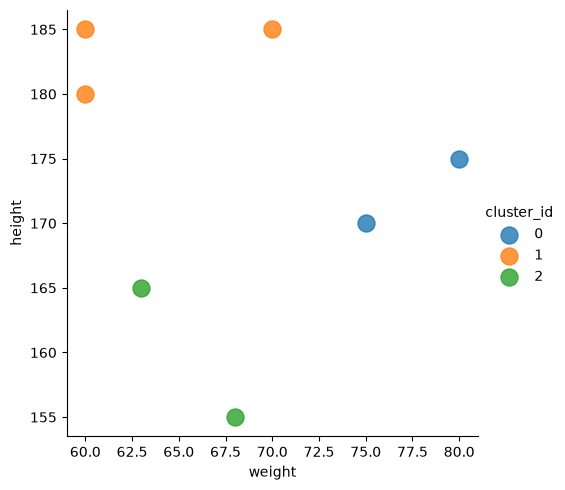

In [22]:
sns.lmplot(data=df, x='weight', y='height', fit_reg=False,
           scatter_kws={'s':150},
           hue='cluster_id')